In [1]:
"""nb2_adenine_riboswitch — reproduces the two adenine-riboswitch maintext figures.

Loads cached BPP matrices from data/cache/adenine_riboswitch/bpp_matrices.npz
and produces:
  - maintext_composite.png            (panels a/b/c-f: arcplot + K_D + zooms)
  - arcplots_by_concentration_grid.png (4x2 arcplot grid by [adenine])

Run from the repo root:
    python notebooks/nb2_adenine_riboswitch.py

Outputs written to: data/cache/adenine_riboswitch/figures/

To regenerate the cached NPZ (when fits change):
    python notebooks/_regenerate_cache_nb2.py
"""

'nb2_adenine_riboswitch — reproduces the two adenine-riboswitch maintext figures.\n\nLoads cached BPP matrices from data/cache/adenine_riboswitch/bpp_matrices.npz\nand produces:\n  - maintext_composite.png            (panels a/b/c-f: arcplot + K_D + zooms)\n  - arcplots_by_concentration_grid.png (4x2 arcplot grid by [adenine])\n\nRun from the repo root:\n    python notebooks/nb2_adenine_riboswitch.py\n\nOutputs written to: data/cache/adenine_riboswitch/figures/\n\nTo regenerate the cached NPZ (when fits change):\n    python notebooks/_regenerate_cache_nb2.py\n'

In [2]:
import argparse
import pathlib
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Arc, Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import curve_fit

try:
    REPO = pathlib.Path(__file__).resolve().parents[2]
except NameError:
    _p = pathlib.Path.cwd().resolve()
    REPO = next(p for p in [_p, *_p.parents] if (p / 'merge_rna').is_dir())

def _parse_args():
    p = argparse.ArgumentParser(description='Plot nb2 adenine riboswitch figures')
    p.add_argument('--cache-dir', default=None,
                   help='Override cache directory (default: data/cache/adenine_riboswitch)')
    p.add_argument('--fig-out', default=None,
                   help='Override figures output directory (default: <cache>/figures)')
    args, _ = p.parse_known_args()
    return args

_ARGS = _parse_args()

def _relpath(path):
    try:
        return str(pathlib.Path(path).resolve().relative_to(REPO))
    except Exception:
        return str(path)

CACHE = pathlib.Path(_ARGS.cache_dir) if _ARGS.cache_dir else REPO / 'data' / 'cache' / 'adenine_riboswitch'
FIG_OUT = pathlib.Path(_ARGS.fig_out) if _ARGS.fig_out else CACHE / 'figures'
FIG_OUT.mkdir(parents=True, exist_ok=True)


def _show_or_note(path):
    try:
        get_ipython()
        from IPython.display import display, Image
        display(Image(str(path)))
    except NameError:
        print(f"  saved -> {_relpath(path)}")

In [3]:
ADE_CONCS = [0, 0.7, 2.1, 6.2, 18.5, 55.6, 166.7, 500]

# Manuscript axis labels: abs_1based position -> label
MAINTEXT_INDEX_ANCHOR = 5
MAINTEXT_START_1BASED = 14

def abs_to_label(abs_1based):
    return (abs_1based - MAINTEXT_START_1BASED) + MAINTEXT_INDEX_ANCHOR + 1

def label_to_abs0b(label):
    abs_1based = label - MAINTEXT_INDEX_ANCHOR - 1 + MAINTEXT_START_1BASED
    return abs_1based - 1

# Reference-figure sequence window (123 nt)
REF_SEQ = ('AAGAUCAACGCUUCAUAUAAUCCUAAUGAUAUGGUUUGGGAGUUUCUACCAAGAGCCUUAAACUCUUGAUUA'
           'UGAAGUCUGUCGCUUUAUCCGAAAUUUUAUAAAGAGAAGACUCAUGAAUUC')

# Domain ranges (manuscript labels)
P1_I_RANGE_LABELS = (14, 21)
P1_J_RANGE_LABELS = (75, 82)
P2_I_RANGE_LABELS = (14, 31)
P2_J_RANGE_LABELS = (37, 47)
P3_I_RANGE_LABELS = (54, 59)
P3_J_RANGE_LABELS = (67, 72)
SD_I_RANGE_LABELS = (76, 98)
SD_J_RANGE_LABELS = (103, 121)

P1_REP_PAIR_LABELS = (17, 79)

# Discrete BPP color bins (arcs and matrices below 0.05 are not drawn).
BPP_BINS = [
    (0.05, 0.25, '#AAAAAA'),  # grey
    (0.25, 0.50, '#E8C84A'),  # yellow
    (0.50, 0.75, '#1565C0'),  # blue
    (0.75, 1.01, '#4CAF50'),  # green
]

# Local arc palette: lighter grey for the lowest BPP bin in panel (a).
_MAINTEXT_BPP_BINS = [
    (0.05, 0.25, '#D8D8D8'),
    (0.25, 0.50, BPP_BINS[1][2]),
    (0.50, 0.75, BPP_BINS[2][2]),
    (0.75, 1.01, BPP_BINS[3][2]),
]

def bpp_color(prob):
    for lo, hi, col in BPP_BINS:
        if lo <= prob < hi:
            return col
    return None

def _mt_arc_color(prob):
    for lo, hi, col in _MAINTEXT_BPP_BINS:
        if lo <= prob < hi:
            return col
    return None

In [4]:
d = np.load(CACHE / 'bpp_matrices.npz', allow_pickle=True)
concentrations = d['concentrations']
bpp_r7 = d['bpp_r7']               # (8, N, N)
bpp_r6_p1pair = d['bpp_r6_p1pair']  # (8,) -- BPP(17,79) for r6 only
seq = str(d['seq'])
N = bpp_r7.shape[1]

ARC_X_START_0B = seq.find(REF_SEQ)
if ARC_X_START_0B < 0:
    raise RuntimeError('Reference sequence window not found in fit sequence')
ARC_X_END_0B = ARC_X_START_0B + len(REF_SEQ) - 1

idx_by_conc = {c: i for i, c in enumerate(ADE_CONCS)}
def bpp_at(conc):
    return bpp_r7[idx_by_conc[conc]]

In [5]:

def _extract_region_block_buffered(bpp, i_rng, j_rng, buffer_nt=0):
    """Return buffered block and displayed i/j label ranges (1-based)."""
    last_label = abs_to_label(N)
    i_disp = (max(1, i_rng[0] - buffer_nt), min(last_label, i_rng[1] + buffer_nt))
    j_disp = (max(1, j_rng[0] - buffer_nt), min(last_label, j_rng[1] + buffer_nt))

    i_abs = np.arange(label_to_abs0b(i_disp[0]), label_to_abs0b(i_disp[1]) + 1)
    j_abs = np.arange(label_to_abs0b(j_disp[0]), label_to_abs0b(j_disp[1]) + 1)

    block = np.zeros((len(i_abs), len(j_abs)), dtype=float)
    for ii, i_pos in enumerate(i_abs):
        for jj, j_pos in enumerate(j_abs):
            if i_pos == j_pos:
                continue
            a, b = (i_pos, j_pos) if i_pos < j_pos else (j_pos, i_pos)
            block[ii, jj] = bpp[a, b]
    return block, i_disp, j_disp


def hill_sigmoid(x, bottom, top, K, n):
    x = np.asarray(x, dtype=float)
    return bottom + (top - bottom) * (x ** n) / (K ** n + x ** n)

Building maintext composite figure ...
  panel (b) Rep. 1: K_D = 1.68 µM, top=0.675, n=3.25
  panel (b) Rep. 2: K_D = 1.71 µM, top=0.666, n=2.04


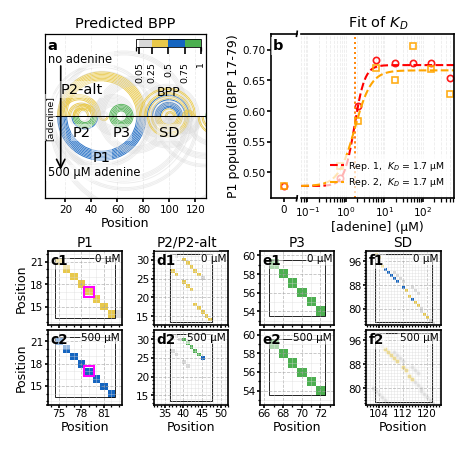

  saved: data/cache/adenine_riboswitch/figures/maintext_composite.png


In [6]:
print("Building maintext composite figure ...")

# Discrete 4-bin colormap matching BPP_BINS (used by zoom panels).
_bin_edges = [0.0, 0.05, 0.25, 0.50, 0.75, 1.0001]
cmap_bpp_4bin_mt = mcolors.ListedColormap(
    ['#FFFFFF'] + [c for _, _, c in _MAINTEXT_BPP_BINS]
)
norm_bpp_4bin_mt = mcolors.BoundaryNorm(_bin_edges, cmap_bpp_4bin_mt.N, clip=True)

# Layout knobs
MULTIPLICATOR = 0.92
FIG_W = 3.5 * MULTIPLICATOR
FIG_H = 3.2 * MULTIPLICATOR
HR_TOP, HR_MID, HR_BOT = 2.2, 1.0, 1.0
HGAP_TOP_MID, HGAP_MID_BOT = 0.7, 0.06
WS_TOP, WS_ZOOM = 0.3, 0.04
B_WSPACE = 0.05
B_W_RATIO = [1, 6]
B_BREAK_D = 0.015
DOMAIN_TAG_Y_P1_FRAC = -0.5
DOMAIN_TAG_Y_P2_FRAC = -0.20
DOMAIN_TAG_Y_P2_ALT_FRAC = 0.32
DOMAIN_TAG_Y_P3_FRAC = -0.20
DOMAIN_TAG_Y_SD_FRAC = -0.20
DOMAIN_TAG_BOX_ALPHA = 0.45
P2_ALT_TITLE_X_FRAC = 0.04
P2_ALT_TITLE_Y_FRAC = 1.02
P2_ALT_TITLE_ALPHA = 0.55
ADJ_LEFT, ADJ_RIGHT = 0.10, 0.97
ADJ_TOP, ADJ_BOTTOM = 0.93, 0.09

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=450)
gs_outer = GridSpec(5, 1, figure=fig, hspace=0,
                    height_ratios=[HR_TOP, HGAP_TOP_MID, HR_MID, HGAP_MID_BOT, HR_BOT])
gs_top = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=WS_TOP)
gs_mid = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[2], wspace=WS_ZOOM)
gs_bot = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[4], wspace=WS_ZOOM)


def _zoom_gs(row, col):
    return (gs_mid if row == 1 else gs_bot)[0, col]


# ---- Panel (a): mirrored arcplot (0 above, 500 below) ----
ax_a = fig.add_subplot(gs_top[0, 0])
bpp_top = bpp_at(0)
bpp_bot = bpp_at(500)
LW_A = 0.45

ax_a.plot([ARC_X_START_0B - 1, ARC_X_END_0B + 1], [0, 0], 'k-', lw=0.5)

for bpp_panel, theta in [(bpp_top, (0, 180)), (bpp_bot, (180, 360))]:
    for i in range(N):
        for j in range(i + 1, N):
            v = bpp_panel[i, j]
            col = _mt_arc_color(v)
            if col is None:
                continue
            cx = (i + j) / 2.0
            w = j - i
            _alpha = 0.45 if v < 0.25 else 0.9
            arc = Arc((cx, 0), w, w, theta1=theta[0], theta2=theta[1],
                      edgecolor=col, linewidth=LW_A, fill=False, alpha=_alpha)
            ax_a.add_patch(arc)

span_a = ARC_X_END_0B - ARC_X_START_0B + 2
half_span_a = span_a / 2.0 * 1.02
ax_a.set_ylim(-half_span_a, half_span_a)
ax_a.set_xlim(ARC_X_START_0B - 1, ARC_X_END_0B + 1)
ax_a.set_aspect('equal', adjustable='box')
ax_a.set_yticks([])
for sp in ('left', 'top', 'right', 'bottom'):
    ax_a.spines[sp].set_visible(True)
    ax_a.spines[sp].set_linewidth(0.6)

tick_pos_a = [i for i in range(N)
              if ARC_X_START_0B <= i <= ARC_X_END_0B and abs_to_label(i + 1) % 20 == 0]
ax_a.set_xticks(tick_pos_a)
ax_a.grid(True, axis='x', color='0.85', lw=0.4, ls='--', alpha=0.5, zorder=0)
ax_a.set_xticklabels([abs_to_label(i + 1) for i in tick_pos_a], fontsize=5)
ax_a.tick_params(axis='x', length=2, pad=1)
ax_a.set_xlabel('Position', fontsize=6, labelpad=1)

_tbg = dict(facecolor='white', edgecolor='none', alpha=0.55, pad=1.0)
ax_a.set_title('Predicted BPP', fontsize=7, pad=3)
ax_a.text(0.02, 0.97, 'a', transform=ax_a.transAxes,
          fontsize=7, ha='left', va='top', fontweight='bold', bbox=_tbg)
ax_a.text(0.02, 0.88, 'no adenine', transform=ax_a.transAxes,
          fontsize=5.5, ha='left', va='top', bbox=_tbg)
ax_a.text(0.02, 0.12, '500 µM adenine', transform=ax_a.transAxes,
          fontsize=5.5, ha='left', va='bottom', bbox=_tbg)
ax_a.annotate('', xy=(0.10, 0.15), xytext=(0.10, 0.83),
              xycoords='axes fraction',
              arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
ax_a.text(0.0055, 0.49, '[adenine]', transform=ax_a.transAxes,
          fontsize=4.5, ha='left', va='center', rotation=90,
          bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=0.5))

domain_tag_specs = [
    ('P1', DOMAIN_TAG_Y_P1_FRAC * half_span_a, P1_I_RANGE_LABELS, P1_J_RANGE_LABELS),
    ('P2', DOMAIN_TAG_Y_P2_FRAC * half_span_a, P2_I_RANGE_LABELS, P2_J_RANGE_LABELS),
    ('P2-alt', DOMAIN_TAG_Y_P2_ALT_FRAC * half_span_a, P2_I_RANGE_LABELS, P2_J_RANGE_LABELS),
    ('P3', DOMAIN_TAG_Y_P3_FRAC * half_span_a, P3_I_RANGE_LABELS, P3_J_RANGE_LABELS),
    ('SD', DOMAIN_TAG_Y_SD_FRAC * half_span_a, SD_I_RANGE_LABELS, SD_J_RANGE_LABELS),
]
for tag, domain_tag_y, i_rng, j_rng in domain_tag_specs:
    label_center = 0.25 * (i_rng[0] + i_rng[1] + j_rng[0] + j_rng[1])
    x_pos = label_to_abs0b(label_center)
    ax_a.text(x_pos, domain_tag_y, tag,
              fontsize=7, ha='center', va='center', fontweight='normal',
              color='black',
              bbox=dict(facecolor='white', edgecolor='none', alpha=DOMAIN_TAG_BOX_ALPHA, pad=0.6))


# ---- Panel (b): P1(17,79) BPP vs [adenine] for r6, r7 with Hill fits ----
_gs_b = gs_top[0, 1].subgridspec(1, 2, wspace=B_WSPACE, width_ratios=B_W_RATIO)
ax_b0 = fig.add_subplot(_gs_b[0, 0])               # left: linear, 0 µM only
ax_b1 = fig.add_subplot(_gs_b[0, 1], sharey=ax_b0)  # right: log, non-zero

x_data = np.asarray(ADE_CONCS, dtype=float)
nonzero_mask = x_data > 0
x_data_nz = x_data[nonzero_mask]
zero_idx = int(np.argmin(x_data))

K_seed = float(np.exp(np.mean(np.log(x_data_nz))))
bounds = ([0.0, 1e-3, 0.1], [1.0, 1e4, 10.0])

log_xmin_b = x_data_nz.min() * 0.1
log_xmax_b = x_data_nz.max() * 1.3
x_fit_log_b = np.logspace(np.log10(log_xmin_b), np.log10(log_xmax_b), 400)

P1_I_ABS, P1_J_ABS = sorted(label_to_abs0b(l) for l in P1_REP_PAIR_LABELS)
vals_r7_p1pair = bpp_r7[:, P1_I_ABS, P1_J_ABS]

variants = [
    ('Rep. 1', 'red',    'o', bpp_r6_p1pair),
    ('Rep. 2', 'orange', 's', vals_r7_p1pair),
]

y_min_seen, y_max_seen = np.inf, -np.inf

for rep_label, color, marker, vals in variants:
    vals_zero = vals[zero_idx]
    vals_nz = vals[nonzero_mask]

    ax_b1.plot(x_data_nz, vals_nz, marker=marker, ls='', color=color,
               ms=3, markerfacecolor='none', mew=0.8, alpha=0.9)
    finite_nz = np.isfinite(vals_nz)
    if finite_nz.any():
        y_min_seen = min(y_min_seen, float(np.nanmin(vals_nz[finite_nz])))
        y_max_seen = max(y_max_seen, float(np.nanmax(vals_nz[finite_nz])))

    if not np.isnan(vals_zero):
        ax_b0.plot(0.0, vals_zero, marker=marker, ls='', color=color,
                   ms=3, markerfacecolor='none', mew=0.8, alpha=0.9)
        y_min_seen = min(y_min_seen, float(vals_zero))
        y_max_seen = max(y_max_seen, float(vals_zero))

        bottom_fixed_b = float(vals_zero)
        def _hill_b(x, top, K, n, _b=bottom_fixed_b):
            return hill_sigmoid(x, _b, top, K, n)
        finite = np.isfinite(vals)
        try:
            popt_b, _ = curve_fit(
                _hill_b, x_data[finite], vals[finite],
                p0=[float(np.nanmax(vals)), K_seed, 1.0],
                bounds=bounds, maxfev=10000,
            )
            kd_val = popt_b[1]
            fit_curve_b = _hill_b(x_fit_log_b, *popt_b)
            ax_b1.plot(x_fit_log_b, fit_curve_b, ls='--', color=color, lw=1.0,
                       label=f'{rep_label},  $K_D$ = {kd_val:.1f} µM')
            ax_b1.axvline(kd_val, color=color, ls=':', lw=0.9, alpha=0.85)
            y_min_seen = min(y_min_seen, float(np.nanmin(fit_curve_b)))
            y_max_seen = max(y_max_seen, float(np.nanmax(fit_curve_b)))
            print(f"  panel (b) {rep_label}: K_D = {kd_val:.2f} µM, top={popt_b[0]:.3f}, n={popt_b[2]:.2f}")
        except Exception as e:
            print(f"  panel (b) {rep_label}: Hill fit failed ({e})")

ax_b1.set_xscale('log')
ax_b1.set_xlim(log_xmin_b, log_xmax_b)
if np.isfinite(y_min_seen) and np.isfinite(y_max_seen):
    y_pad = max(0.02, 0.08 * (y_max_seen - y_min_seen))
    ax_b1.set_ylim(max(0.0, y_min_seen - y_pad), min(1.0, y_max_seen + y_pad))
ax_b1.set_xlabel('[adenine] (µM)', fontsize=6, labelpad=1)
ax_b1.tick_params(axis='both', labelsize=5, pad=1, length=2)
ax_b1.grid(True, which='both', axis='x', color='0.85', lw=0.4, ls='--', alpha=0.5, zorder=0)
ax_b1.legend(fontsize=4.5, frameon=True, framealpha=0.7, edgecolor='none',
             loc='lower right', handlelength=1.5, handletextpad=0.4,
             borderpad=0.5, labelspacing=0.35)
ax_b1.spines['left'].set_visible(False)
ax_b1.tick_params(left=False, labelleft=False)

ax_b0.set_xlim(-0.5, 0.5)
ax_b0.set_xticks([0])
ax_b0.set_xticklabels(['0'], fontsize=5)
ax_b0.tick_params(axis='y', labelleft=True, left=True, right=False, labelright=False)
ax_b0.tick_params(axis='both', labelsize=5, pad=1, length=2)
ax_b0.spines['right'].set_visible(False)
ax_b0.set_ylabel(f'P1 population (BPP {P1_REP_PAIR_LABELS[0]}-{P1_REP_PAIR_LABELS[1]})',
                 fontsize=6, labelpad=1)

# Diagonal break marks
_d = B_BREAK_D
_bkw = dict(transform=ax_b0.transAxes, color='k', lw=0.8, clip_on=False)
ax_b0.plot((1 - _d, 1 + _d), (-_d, +_d), **_bkw)
ax_b0.plot((1 - _d, 1 + _d), (1 - _d, 1 + _d), **_bkw)

ax_b1.set_title('Fit of $K_D$', fontsize=7, pad=3)
ax_b0.text(0.07, 0.97, 'b', transform=ax_b0.transAxes,
           fontsize=7, ha='left', va='top', fontweight='bold',
           bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=1.0))


# ---- Panels (c-f): zoom matrices at 0 and 500 µM ----
region_layout = [
    ('c', 'P1', 'P1', P1_I_RANGE_LABELS, P1_J_RANGE_LABELS, 0),
    ('d', 'P2', 'P2/P2-alt', P2_I_RANGE_LABELS, P2_J_RANGE_LABELS, 1),
    ('e', 'P3', 'P3', P3_I_RANGE_LABELS, P3_J_RANGE_LABELS, 2),
    ('f', 'SD', 'SD', SD_I_RANGE_LABELS, SD_J_RANGE_LABELS, 3),
]
ZOOM_BUFFER = 1
extreme_concs_mt = [0, 500]
last_im = None

for panel_letter, region_name, region_title, i_rng, j_rng, gs_col in region_layout:
    i_disp_base = (i_rng[0] - ZOOM_BUFFER, i_rng[1] + ZOOM_BUFFER)
    j_disp_base = (j_rng[0] - ZOOM_BUFFER, j_rng[1] + ZOOM_BUFFER)
    i_center = (i_disp_base[0] + i_disp_base[1]) / 2.0
    j_center = (j_disp_base[0] + j_disp_base[1]) / 2.0
    half = max(i_disp_base[1] - i_disp_base[0],
               j_disp_base[1] - j_disp_base[0]) / 2.0
    i_view = (i_center - half, i_center + half)
    j_view = (j_center - half, j_center + half)

    ax_top = ax_bot = None
    for k, conc in enumerate(extreme_concs_mt):
        ax = fig.add_subplot(_zoom_gs(k + 1, gs_col))
        if k == 0:
            ax_top = ax
        else:
            ax_bot = ax

        block, i_disp, j_disp = _extract_region_block_buffered(
            bpp_at(conc), i_rng, j_rng, buffer_nt=ZOOM_BUFFER)

        im = ax.imshow(
            block,
            origin='lower',
            cmap=cmap_bpp_4bin_mt,
            norm=norm_bpp_4bin_mt,
            aspect='auto',
            extent=[j_disp[0] - 0.5, j_disp[1] + 0.5,
                    i_disp[0] - 0.5, i_disp[1] + 0.5],
        )
        last_im = im

        ax.add_patch(Rectangle((j_rng[0] - 0.5, i_rng[0] - 0.5),
                               j_rng[1] - j_rng[0] + 1,
                               i_rng[1] - i_rng[0] + 1,
                               fill=False, edgecolor='black', linewidth=0.4))

        if region_name == 'P1':
            pi, pj = P1_REP_PAIR_LABELS
            ax.plot(pj, pi, marker='s', ms=5, mfc='none',
                    mec='magenta', mew=1.0)

        ax.set_xlim(j_view[0] - 0.5, j_view[1] + 0.5)
        ax.set_ylim(i_view[0] - 0.5, i_view[1] + 0.5)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
        ax.xaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.grid(which='minor', color='0.85', lw=0.25, alpha=0.7)
        ax.grid(which='major', color='0.65', lw=0.4, ls='--', alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=5, pad=0.5, length=1.5)
        ax.tick_params(axis='both', which='minor', length=0.8)
        ax.set_box_aspect(1)
        ax.set_xlabel('Position' if k == 1 else '', fontsize=6, labelpad=1)
        ax.set_ylabel('Position' if gs_col == 0 else '', fontsize=6, labelpad=1)
        if k == 0:
            ax.tick_params(labelbottom=False)

        sub_label = f'{panel_letter}{k + 1}'
        if k == 0:
            if region_name == 'P2':
                ax.text(P2_ALT_TITLE_X_FRAC, P2_ALT_TITLE_Y_FRAC, region_title,
                        transform=ax.transAxes, fontsize=6.5, ha='left', va='bottom',
                        fontweight='normal', color='black', clip_on=False,
                        bbox=dict(facecolor='white', edgecolor='none',
                                  alpha=P2_ALT_TITLE_ALPHA, pad=0.8))
            else:
                ax.set_title(region_title, fontsize=6.5, pad=2)
        ax.text(0.04, 0.96, sub_label, transform=ax.transAxes,
                fontsize=6.5, ha='left', va='top', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=0.8))

    _tbg2 = dict(facecolor='white', edgecolor='none', alpha=0.55, pad=0.5)
    ax_top.text(0.97, 0.96, '0 µM', transform=ax_top.transAxes,
                fontsize=5, ha='right', va='top', bbox=_tbg2)
    ax_bot.text(0.97, 0.96, '500 µM', transform=ax_bot.transAxes,
                fontsize=5, ha='right', va='top', bbox=_tbg2)

# Colorbar inside (a)
cax_inset = inset_axes(ax_a, width='40%', height='5%', loc='upper right', borderpad=0.25)
cbar = fig.colorbar(last_im, cax=cax_inset, orientation='horizontal',
                    ticks=[0.05, 0.25, 0.50, 0.75, 1.0],
                    spacing='proportional')
cbar.ax.set_xticklabels(['0.05', '0.25', '0.5', '0.75', '1'], fontsize=4.5, rotation=90)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.set_label('BPP', fontsize=6, labelpad=1.5)
cbar.outline.set_linewidth(0.4)

fig.subplots_adjust(left=ADJ_LEFT, right=ADJ_RIGHT, top=ADJ_TOP, bottom=ADJ_BOTTOM)

out = FIG_OUT / 'maintext_composite.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.close('all')
_show_or_note(out)
print(f'  saved: {_relpath(out)}')


Building arcplot-by-concentration figure ...


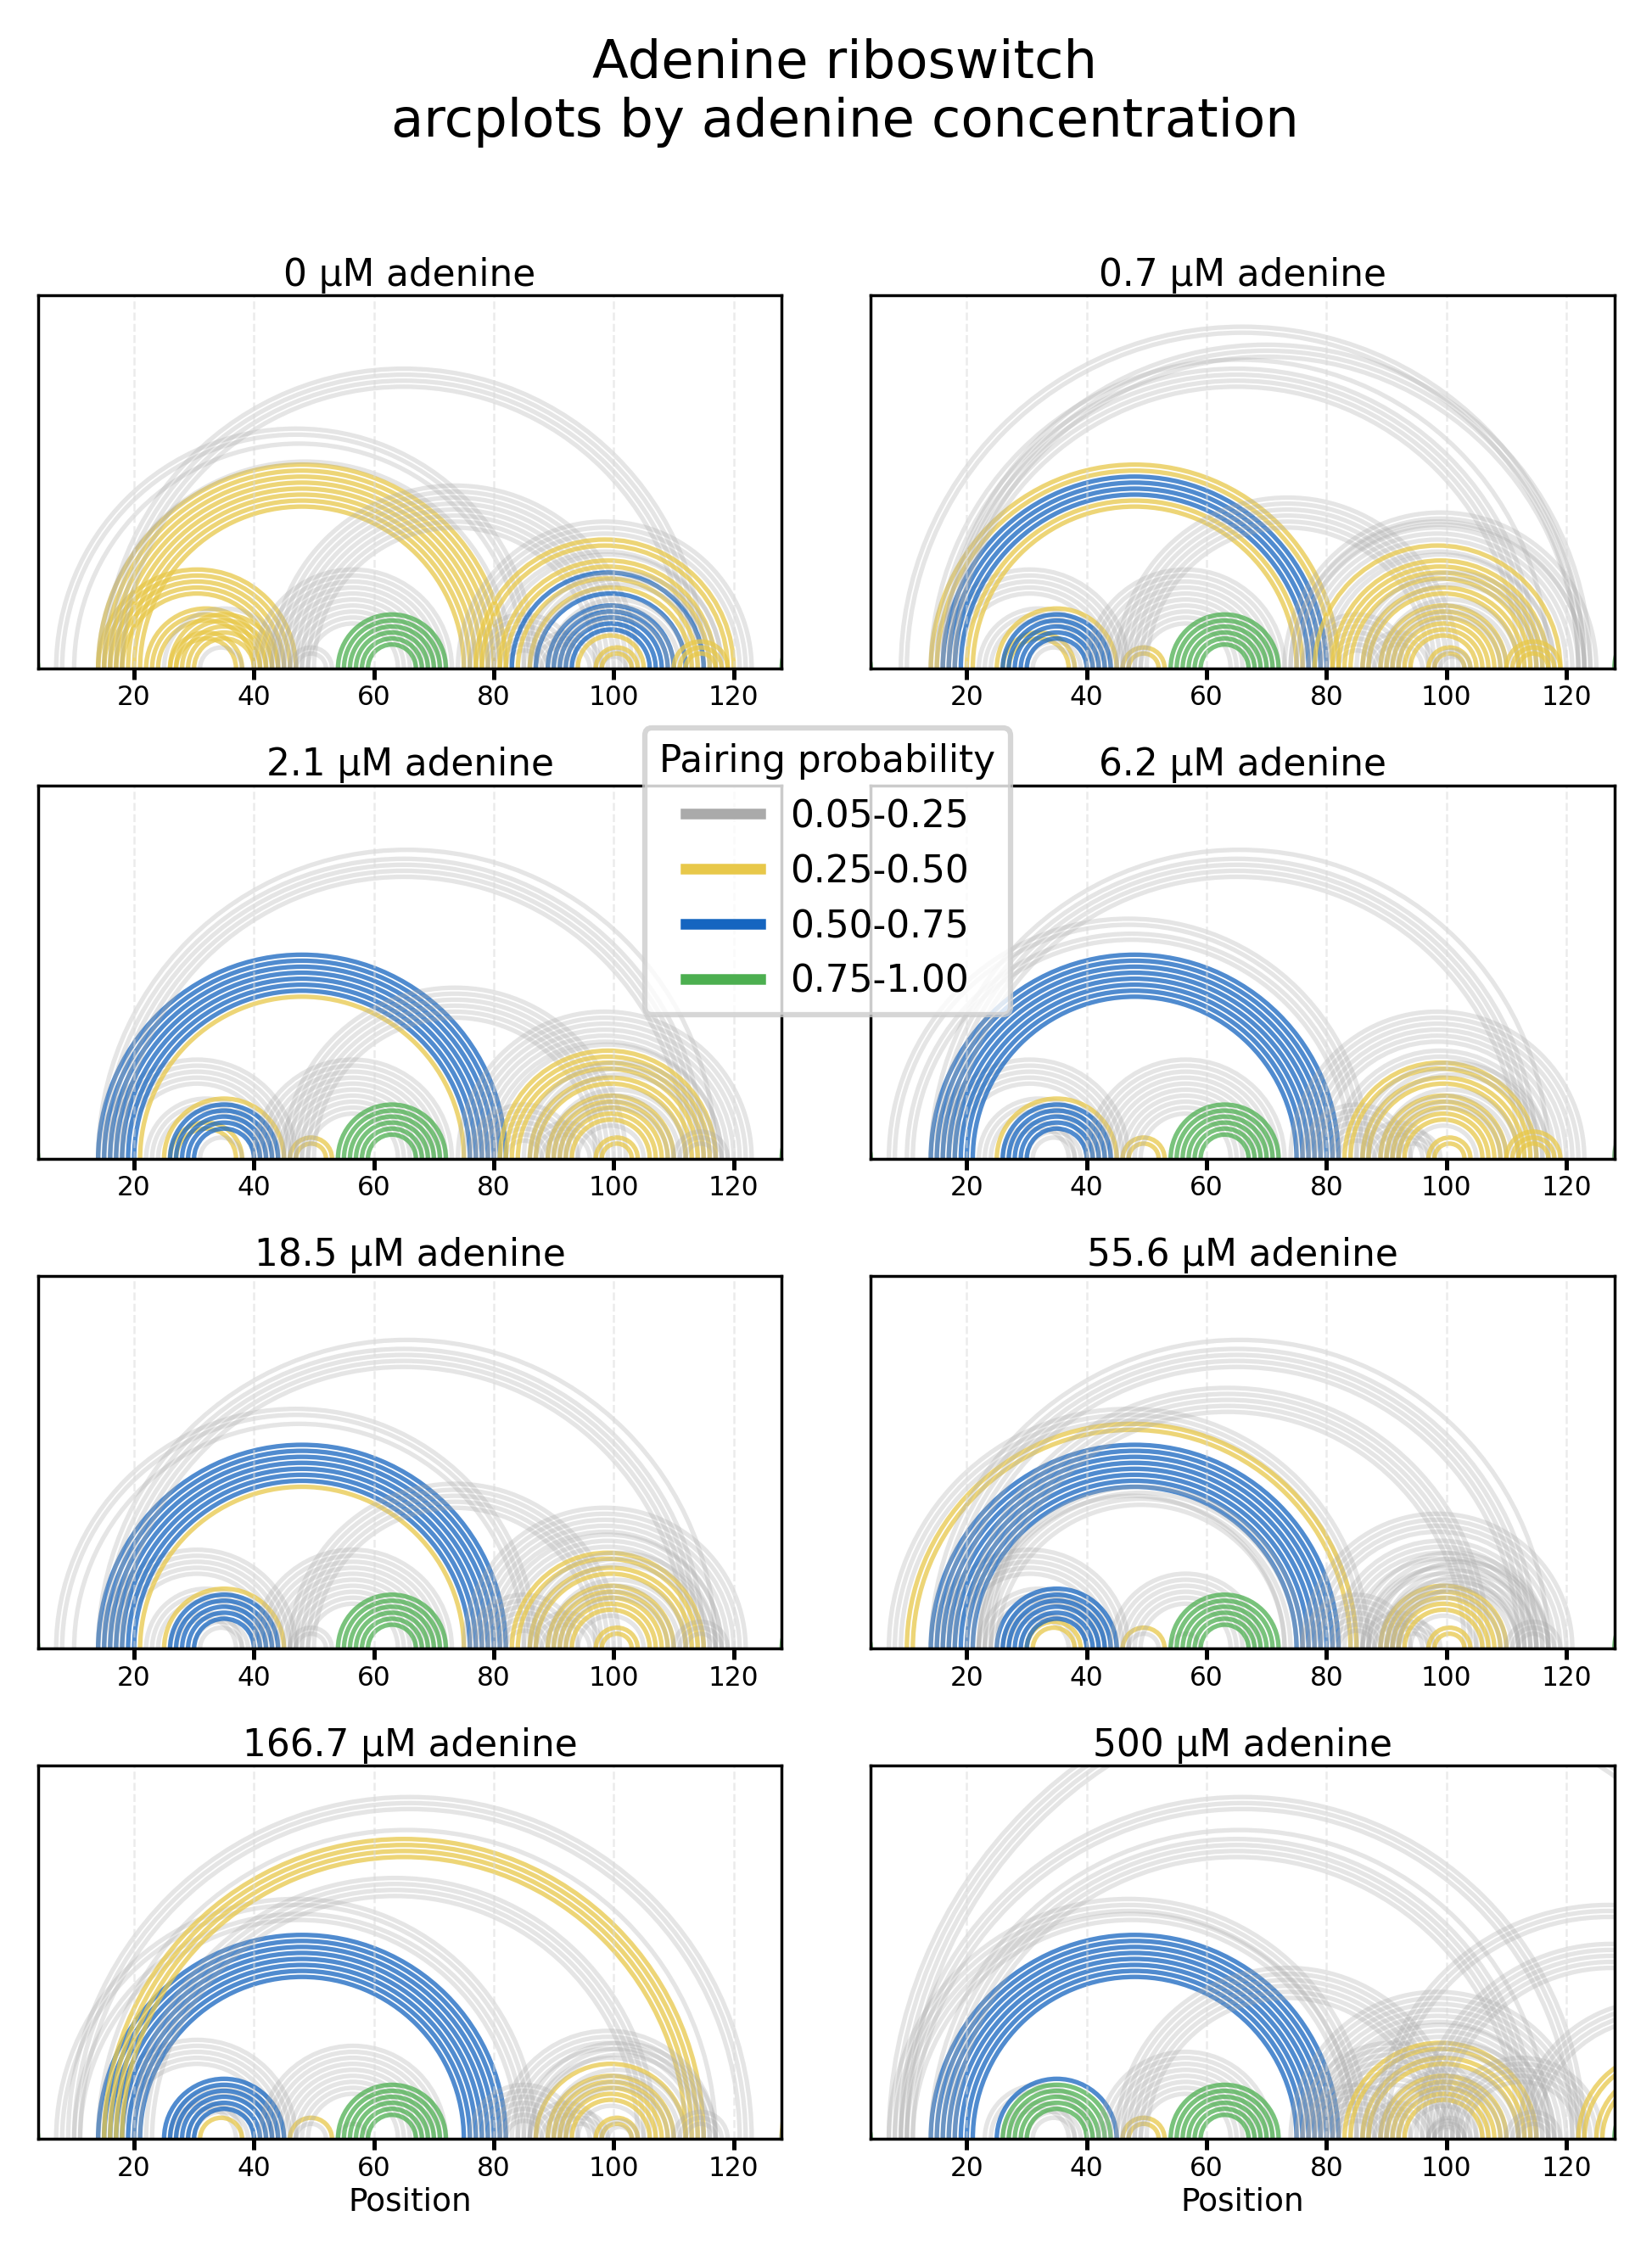

  saved: data/cache/adenine_riboswitch/figures/arcplots_by_concentration_grid.png

Done.


In [7]:
print("\nBuilding arcplot-by-concentration figure ...")
SCALE = 1.2
nrows_arcgrid, ncols_arcgrid = 4, 2

fig_arcgrid, axes_arcgrid = plt.subplots(
    nrows_arcgrid, ncols_arcgrid,
    figsize=(4.00 * SCALE, 5 * SCALE),
    sharex=True, sharey=False, dpi=450,
)
axes_arcgrid = np.asarray(axes_arcgrid).ravel()


def _draw_single_arc_panel(ax, bpp, conc, is_bottom=False):
    conc_str = f'{conc} µM'
    ax.plot([ARC_X_START_0B - 1, ARC_X_END_0B + 1], [0, 0], 'k-', lw=0.5)
    for i in range(N):
        for j in range(i + 1, N):
            col = bpp_color(bpp[i, j])
            if col is None:
                continue
            cx = (i + j) / 2.0
            w = j - i
            _alpha = 0.3 if col == '#AAAAAA' else 0.75
            arc = Arc((cx, 0), w, w, theta1=0, theta2=180,
                      edgecolor=col, linewidth=0.85, fill=False, alpha=_alpha)
            ax.add_patch(arc)

    span_x = ARC_X_END_0B - ARC_X_START_0B + 2
    ax.set_xlim(ARC_X_START_0B - 1, ARC_X_END_0B + 1)
    ax.set_ylim(-0, span_x / 2.0 + 0.2)
    ax.set_yticks([])
    ax.grid(True, axis='x', color='0.85', lw=0.4, ls='--', alpha=0.5, zorder=0)
    ax.set_aspect('equal', adjustable='box')

    tick_pos = [i for i in range(N)
                if ARC_X_START_0B <= i <= ARC_X_END_0B and abs_to_label(i + 1) % 20 == 0]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([abs_to_label(i + 1) for i in tick_pos], fontsize=5)
    ax.tick_params(axis='x', length=2, pad=1)
    if is_bottom:
        ax.set_xlabel('Position', fontsize=6, labelpad=1)
    else:
        ax.tick_params(labelbottom=True)

    for sp in ('left', 'top', 'right', 'bottom'):
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(0.55)

    ax.set_title(conc_str + ' adenine', fontsize=7, pad=2)


for ax, conc in zip(axes_arcgrid, ADE_CONCS):
    _draw_single_arc_panel(ax, bpp_at(conc), conc, is_bottom=False)

# Bottom-row x-labels
for ax in axes_arcgrid[max(0, len(ADE_CONCS) - ncols_arcgrid):len(ADE_CONCS)]:
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('Position', fontsize=6, labelpad=1)

arc_legend_handles = [
    Line2D([0], [0], color=col, lw=2, label=f'{lo:.2f}-{min(hi, 1.0):.2f}')
    for lo, hi, col in BPP_BINS
]
fig_arcgrid.legend(handles=arc_legend_handles, loc=(0.39, 0.55), fontsize=7,
                   title='Pairing probability', title_fontsize=7)
fig_arcgrid.suptitle('Adenine riboswitch\narcplots by adenine concentration',
                     fontsize=10, y=0.995)
fig_arcgrid.subplots_adjust(left=0.06, right=0.92, top=0.90, bottom=0.06,
                            hspace=0.08, wspace=0.12)

out_arcgrid = FIG_OUT / 'arcplots_by_concentration_grid.png'
fig_arcgrid.savefig(out_arcgrid, dpi=450, bbox_inches='tight')
plt.close('all')
_show_or_note(out_arcgrid)
print(f'  saved: {_relpath(out_arcgrid)}')

print("\nDone.")